# Diabetes Prediction — Machine Learning Project


### Project objective
Build a classification model that predicts whether a person is likely to have diabetes (`Outcome = 1`) or not (`Outcome = 0`) using the Pima Indians Diabetes dataset.

### Complete workflow
1. Import libraries
2. Load dataset
3. Understand the dataset
4. Check data quality
5. Exploratory Data Analysis (EDA)
6. Handle invalid/missing values
7. Separate features and target
8. Train-test split
9. Feature scaling
10. Train multiple classification models
11. Evaluate models
12. Compare models
13. Select the best model
14. Test with a new patient
15. Save the model and scaler
16. Verify the saved model


## Step 1 — Import libraries

We will use:
- **Pandas** for data handling
- **NumPy** for numerical operations
- **Matplotlib / Seaborn** for visualization
- **Scikit-learn** for machine learning
- **Joblib** to save the trained model and scaler


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 — Load the dataset


In [2]:
# Load dataset
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (768, 9)


## Step 3 — View the first records

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,124,74,37,92,33.6,0.572,37,1
1,5,76,55,27,104,20.7,0.387,57,0
2,6,89,68,37,241,35.8,0.692,21,0
3,7,98,71,44,37,29.4,0.377,36,0
4,1,147,66,47,431,30.7,0.498,24,0


## Step 4 — Understand rows and columns

- `shape` → number of rows and columns
- `columns` → column names
- `dtypes` → data types

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


## Step 6 — Statistical summary

`describe()` gives statistics such as mean, standard deviation, minimum, maximum and quartiles.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.777344,1.936719,0.000,2.000,4.000,5.000,11.000
Glucose,768.0,119.417969,30.256764,50.000,98.000,120.000,139.250,199.000
BloodPressure,768.0,73.164062,12.311755,24.000,65.000,74.000,81.000,112.000
SkinThickness,768.0,29.388021,9.156496,7.000,23.000,29.000,36.000,58.000
Insulin,768.0,148.299479,106.507476,16.000,78.750,114.500,184.250,846.000
BMI,768.0,31.869010,7.501922,18.200,26.600,31.600,37.025,63.400
DiabetesPedigreeFunction,768.0,0.501190,0.173877,0.137,0.383,0.475,0.598,1.232
Age,768.0,34.007812,10.456089,21.000,25.000,33.000,40.000,74.000
Outcome,768.0,0.449219,0.497739,0.000,0.000,0.000,1.000,1.000


## Step 7 — Check missing values

Before training a model, always check whether data is missing.


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.777344,1.936719,0.000,2.000,4.000,5.000,11.000
Glucose,768.0,119.417969,30.256764,50.000,98.000,120.000,139.250,199.000
BloodPressure,768.0,73.164062,12.311755,24.000,65.000,74.000,81.000,112.000
SkinThickness,768.0,29.388021,9.156496,7.000,23.000,29.000,36.000,58.000
Insulin,768.0,148.299479,106.507476,16.000,78.750,114.500,184.250,846.000
BMI,768.0,31.869010,7.501922,18.200,26.600,31.600,37.025,63.400
DiabetesPedigreeFunction,768.0,0.501190,0.173877,0.137,0.383,0.475,0.598,1.232
Age,768.0,34.007812,10.456089,21.000,25.000,33.000,40.000,74.000
Outcome,768.0,0.449219,0.497739,0.000,0.000,0.000,1.000,1.000


## Step 8 — Check duplicate rows

In [9]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


Outcome
0    423
1    345
Name: count, dtype: int64


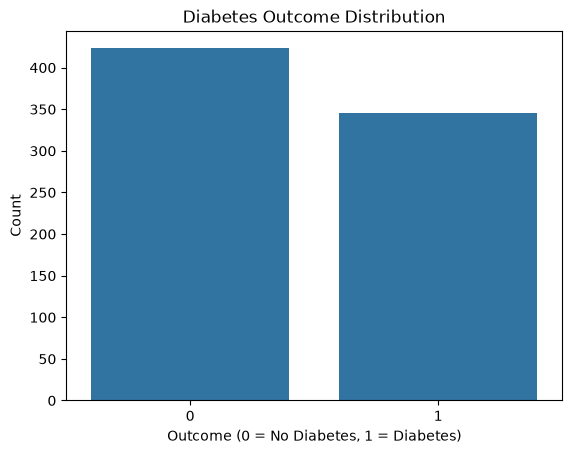

In [10]:
print(df["Outcome"].value_counts())

sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

In [11]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in invalid_zero_columns:
    print(f"{col}: {(df[col] == 0).sum()} zero values")

Glucose: 0 zero values
BloodPressure: 0 zero values
SkinThickness: 0 zero values
Insulin: 0 zero values
BMI: 0 zero values


In [12]:
df[invalid_zero_columns] = df[invalid_zero_columns].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [13]:
for col in invalid_zero_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


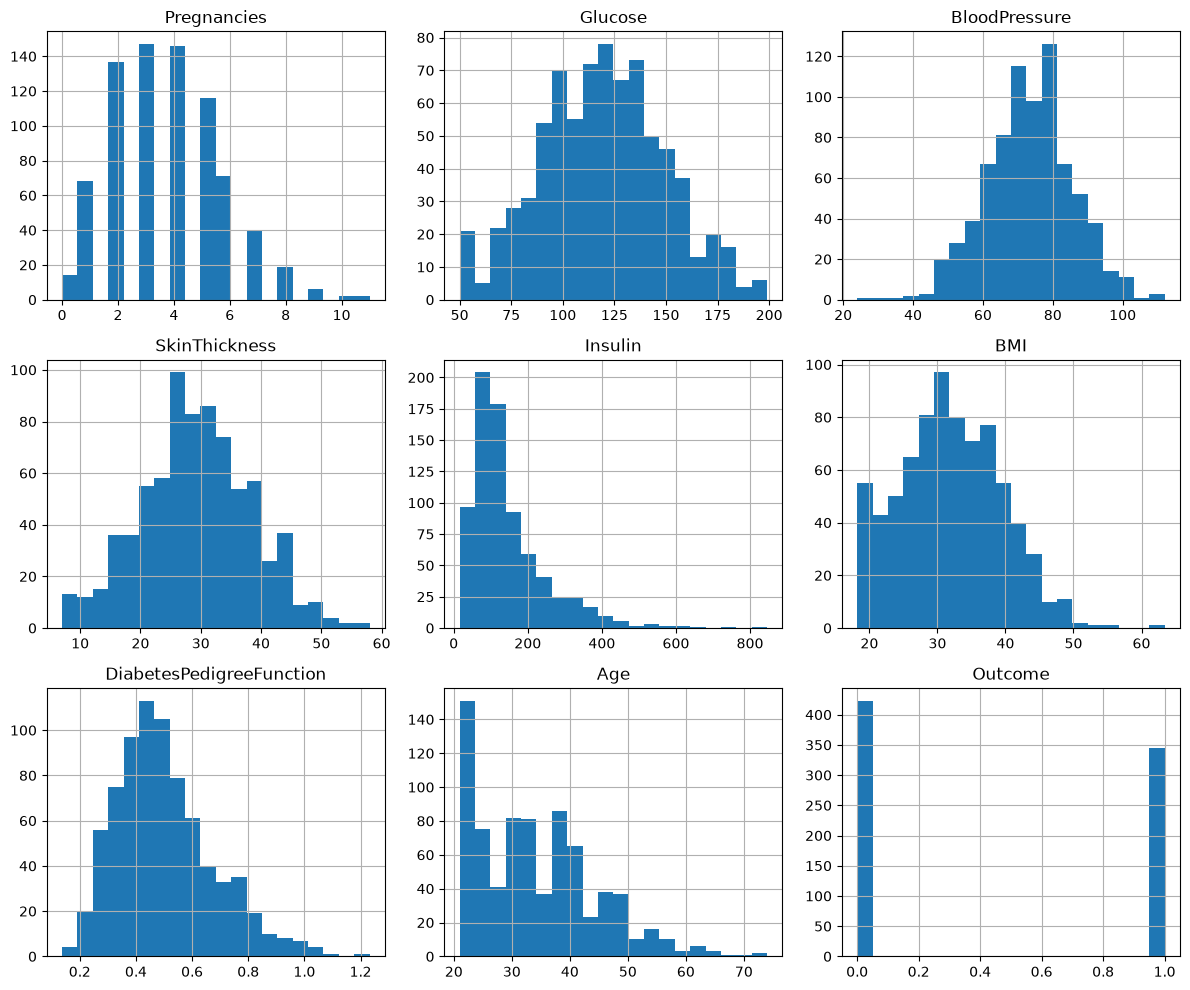

In [14]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

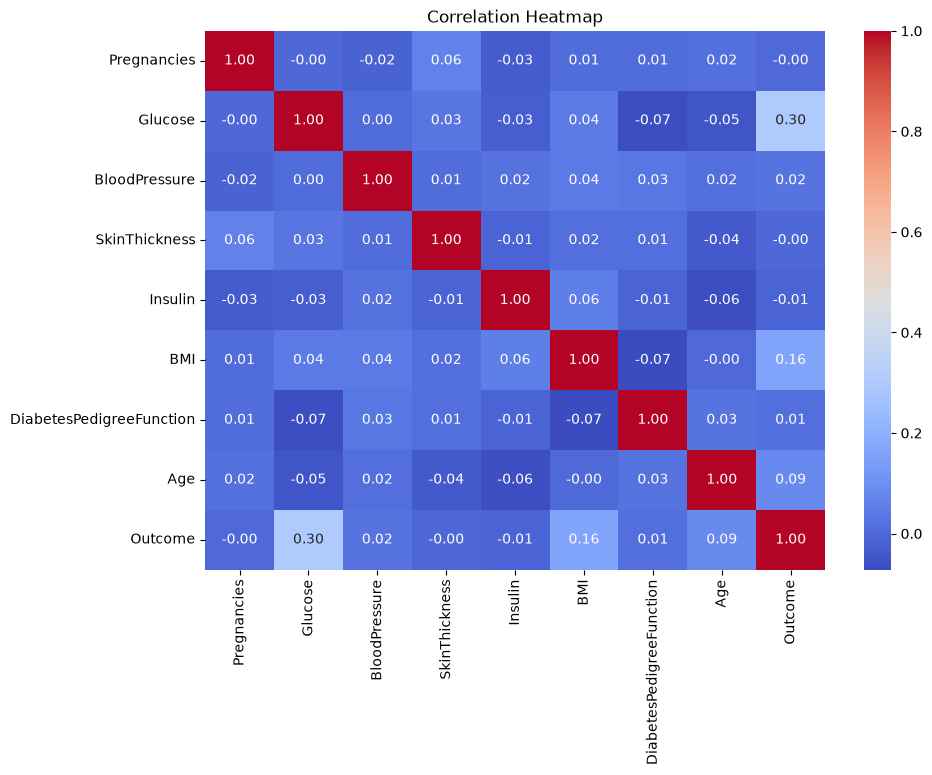

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


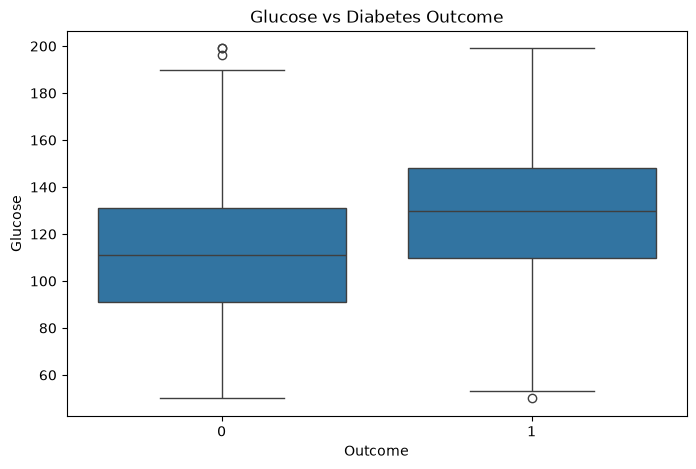

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.show()

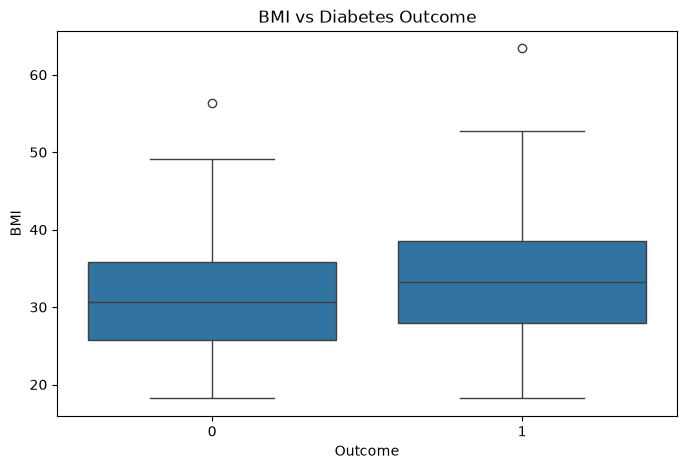

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.show()

In [18]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (614, 8)
Testing data: (154, 8)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [21]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression
Accuracy: 0.7077922077922078


In [22]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.74      0.72      0.73        85
           1       0.67      0.70      0.68        69

    accuracy                           0.71       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.71      0.71      0.71       154



In [23]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree
Accuracy: 0.6363636363636364


In [24]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.84      0.42      0.56        85
           1       0.56      0.90      0.69        69

    accuracy                           0.64       154
   macro avg       0.70      0.66      0.63       154
weighted avg       0.71      0.64      0.62       154



In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest
Accuracy: 0.6363636363636364


In [26]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.65      0.74      0.69        85
           1       0.61      0.51      0.56        69

    accuracy                           0.64       154
   macro avg       0.63      0.62      0.62       154
weighted avg       0.63      0.64      0.63       154



In [27]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))

KNN
Accuracy: 0.6103896103896104


In [28]:
models = {
    "Logistic Regression": log_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.636364,0.558559,0.898551,0.688889
0,Logistic Regression,0.707792,0.666667,0.695652,0.680851
2,Random Forest,0.636364,0.614035,0.507246,0.555556
3,KNN,0.610390,0.569231,0.536232,0.552239


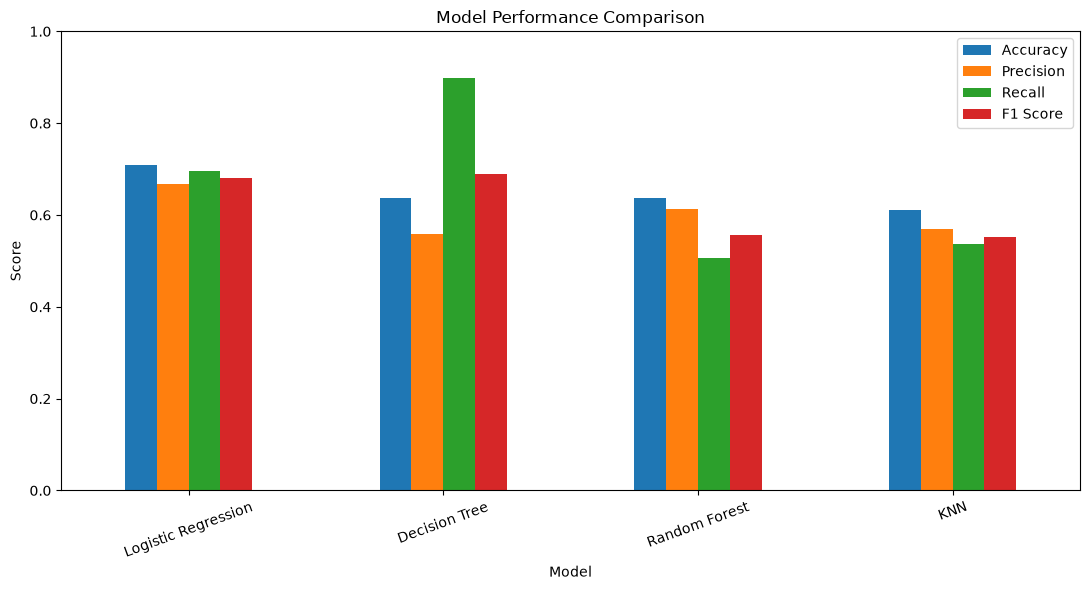

In [29]:
results_plot = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

results_plot.plot(kind="bar", figsize=(11, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


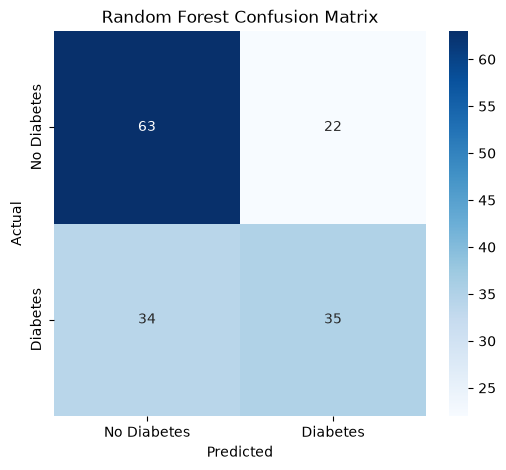

In [30]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [32]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Glucose                     0.196623
BMI                         0.152104
DiabetesPedigreeFunction    0.138106
Insulin                     0.131439
SkinThickness               0.112171
BloodPressure               0.104975
Age                         0.094522
Pregnancies                 0.070059
dtype: float64


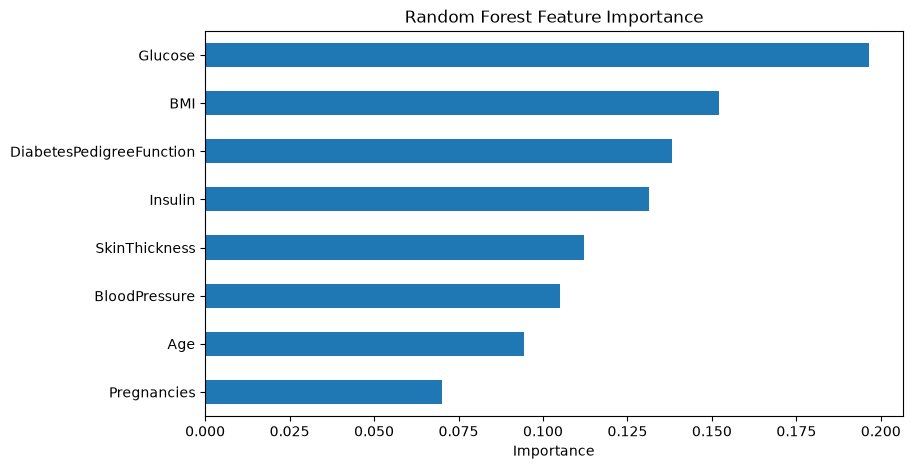

In [33]:
plt.figure(figsize=(9, 5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()


In [34]:
final_model = rf_model

print("Final model selected: Random Forest")

Final model selected: Random Forest


In [35]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 25,
    "Insulin": 100,
    "BMI": 30.5,
    "DiabetesPedigreeFunction": 0.4,
    "Age": 35
}])

new_prediction = final_model.predict(new_patient)[0]
new_probability = final_model.predict_proba(new_patient)[0][1]

print("Prediction:", new_prediction)
print("Probability of class 1:", round(new_probability, 3))

if new_prediction == 1:
    print("Model prediction: Diabetes")
else:
    print("Model prediction: No Diabetes")

Prediction: 0
Probability of class 1: 0.39
Model prediction: No Diabetes


In [36]:
joblib.dump(final_model, "diabetes_model.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")
joblib.dump(list(X.columns), "diabetes_features.pkl")

print("Model saved as: diabetes_model.pkl")
print("Scaler saved as: diabetes_scaler.pkl")
print("Feature list saved as: diabetes_features.pkl")


Model saved as: diabetes_model.pkl
Scaler saved as: diabetes_scaler.pkl
Feature list saved as: diabetes_features.pkl


In [37]:
loaded_model = joblib.load("diabetes_model.pkl")
loaded_features = joblib.load("diabetes_features.pkl")

loaded_prediction = loaded_model.predict(new_patient[loaded_features])[0]

print("Loaded model prediction:", loaded_prediction)


Loaded model prediction: 0
